visualize

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def plot_transition_graph(
    probs_path="transition_probs.npy",
    out_png="transition_graph.png",
    out_pdf="transition_graph.pdf",
    topk_per_node=3,
    min_prob=0.05,
    max_nodes=80,
    seed=42,
):
    P = np.load(probs_path).astype(np.float64)  # shape (K,K)
    K = P.shape[0]

    # Optionally restrict to a subset of nodes (here: keep first max_nodes if K larger)
    nodes = list(range(min(K, max_nodes)))

    G = nx.DiGraph()
    G.add_nodes_from(nodes)

    # Add edges: for each node, keep top-k outgoing edges above min_prob
    for i in nodes:
        row = P[i].copy()
        # remove self-loop if you prefer
        # row[i] = 0.0
        top_idx = np.argsort(-row)[:topk_per_node]
        for j in top_idx:
            if j in nodes and row[j] >= min_prob:
                G.add_edge(i, j, weight=float(row[j]))

    # If graph is empty, relax thresholds
    if G.number_of_edges() == 0:
        raise RuntimeError("Graph has 0 edges. Reduce min_prob or increase topk_per_node.")

    # Layout
    pos = nx.spring_layout(G, seed=seed)

    plt.figure(figsize=(12, 10))
    # Node sizes proportional to out-degree (simple proxy)
    out_deg = dict(G.out_degree())
    node_sizes = [300 + 80 * out_deg.get(n, 0) for n in G.nodes()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, linewidths=0.8)
    nx.draw_networkx_labels(G, pos, font_size=8)

    # Edge widths proportional to weight
    weights = np.array([G[u][v]["weight"] for u, v in G.edges()], dtype=np.float64)
    w_min, w_max = float(weights.min()), float(weights.max())
    if w_max > w_min:
        widths = 0.5 + 4.0 * (weights - w_min) / (w_max - w_min)
    else:
        widths = np.full_like(weights, 2.0)

    nx.draw_networkx_edges(G, pos, width=widths, arrows=True, arrowsize=12)

    plt.title(f"Transition Graph (top-{topk_per_node} per node, min_prob={min_prob})")
    plt.axis("off")
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.savefig(out_pdf)
    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")



Saved: transition_graph.png
Saved: transition_graph.pdf


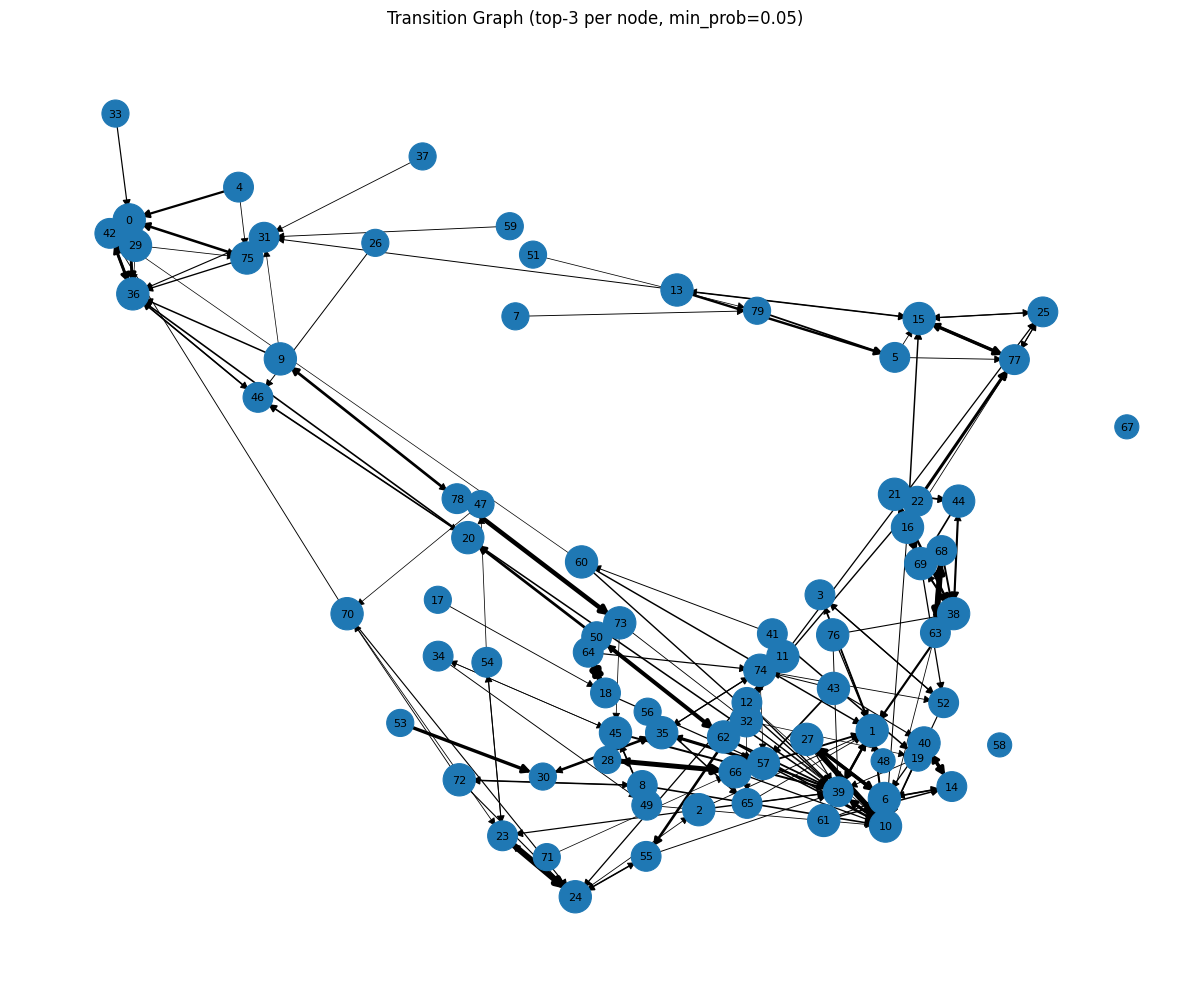

In [2]:
plot_transition_graph()

plot_similarity_hist

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

def l2_normalize(x, eps=1e-12):
    n = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(n, eps, None)

def compute_cosine_pairs(X, pairs, block=200000):
    sims = []
    for i in range(0, len(pairs), block):
        batch = pairs[i:i+block]
        A = np.array([p[0] for p in batch], dtype=np.int64)
        B = np.array([p[1] for p in batch], dtype=np.int64)
        sims.append(np.sum(X[A] * X[B], axis=1))
    return np.concatenate(sims) if sims else np.array([], dtype=np.float32)

def sample_pairs_same_cluster(idx_by_cluster, n_pairs, rng):
    pairs = []
    clusters = [c for c, idxs in idx_by_cluster.items() if len(idxs) >= 2]
    for _ in range(n_pairs):
        c = rng.choice(clusters)
        a, b = rng.sample(idx_by_cluster[c], 2)
        pairs.append((a, b))
    return pairs

def sample_pairs_diff_cluster(idx_by_cluster, n_pairs, rng):
    pairs = []
    clusters = [c for c, idxs in idx_by_cluster.items() if len(idxs) >= 1]
    for _ in range(n_pairs):
        c1, c2 = rng.sample(clusters, 2)
        a = rng.choice(idx_by_cluster[c1])
        b = rng.choice(idx_by_cluster[c2])
        pairs.append((a, b))
    return pairs

def plot_similarity_hist(
    fused_npy="processed_data/fused/fused_embeddings.npy",
    cluster_tsv="processed_data/clusters/screen_clusters.tsv",
    out_png="similarity_hist.png",
    out_pdf="similarity_hist.pdf",
    n_pairs=20000,
    seed=42,
    bins=200
):
    # Load fused vectors if you saved them.
    # If you didn't, you can create fused_embeddings.npy once by concatenating (clip, text) normalized.
    X = np.load(fused_npy).astype(np.float32)
    X = l2_normalize(X)

    df = pd.read_csv(cluster_tsv, sep="\t")
    # df must align with X row order; easiest is to generate fused_npy in the same order as df.
    # If not aligned, regenerate fused_npy from your aligned pipeline.

    cluster_ids = df["cluster_id"].astype(int).values
    idx_by_cluster = {}
    for i, c in enumerate(cluster_ids):
        idx_by_cluster.setdefault(int(c), []).append(i)

    rng = random.Random(seed)
    same_pairs = sample_pairs_same_cluster(idx_by_cluster, n_pairs, rng)
    diff_pairs = sample_pairs_diff_cluster(idx_by_cluster, n_pairs, rng)

    same_sims = compute_cosine_pairs(X, same_pairs)
    diff_sims = compute_cosine_pairs(X, diff_pairs)

    plt.figure(figsize=(10, 5))
    plt.hist(same_sims, bins=bins, alpha=0.6, label="Intra-cluster")
    plt.hist(diff_sims, bins=bins, alpha=0.6, label="Inter-cluster")
    plt.title("Cosine Similarity Distributions (Fused Embeddings)")
    plt.xlabel("Cosine similarity")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=200)
    plt.savefig(out_pdf)
    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    print(cluster_tsv)
    print("=== Intra vs Inter Cluster Cosine Similarity (FUSED) ===")
    print(f"pairs (same cluster): {len(same_sims)}")
    print(f"pairs (diff cluster): {len(diff_sims)}")
    print(f"intra mean={same_sims.mean():.4f} std={same_sims.std():.4f} median={np.median(same_sims):.4f}")
    print(f"inter mean={diff_sims.mean():.4f} std={diff_sims.std():.4f} median={np.median(diff_sims):.4f}")
    print(f"gap (mean intra - mean inter) = {(same_sims.mean()-diff_sims.mean()):.4f}")





Saved: similarity_hist.png
Saved: similarity_hist.pdf
processed_data/clusters/screen_clusters.tsv
=== Intra vs Inter Cluster Cosine Similarity (FUSED) ===
pairs (same cluster): 20000
pairs (diff cluster): 20000
intra mean=0.6829 std=0.1086 median=0.6801
inter mean=0.5601 std=0.0806 median=0.5626
gap (mean intra - mean inter) = 0.1229


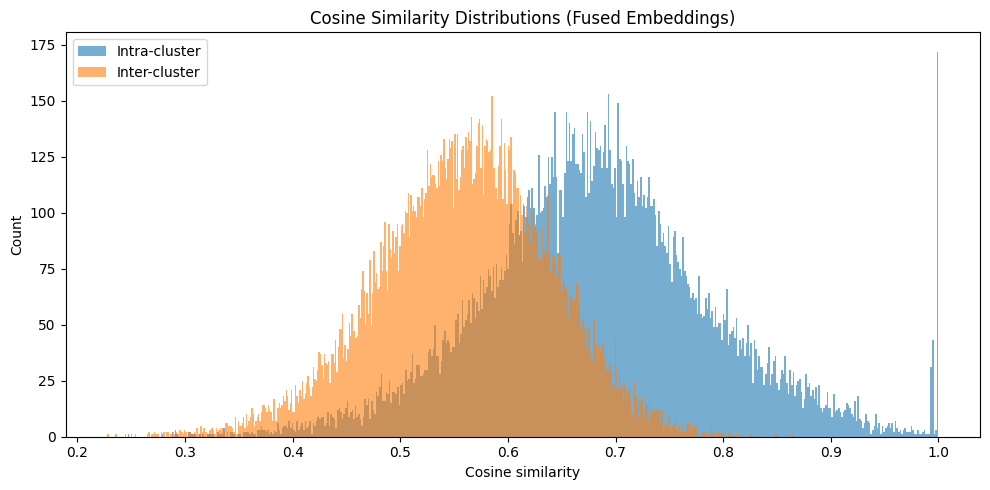

In [21]:
plot_similarity_hist()

Saved: graphs/similarity_hist_k20.png
Saved: graphs/similarity_hist_k20.pdf
processed_data/clusters/screen_clusters_k20.tsv
=== Intra vs Inter Cluster Cosine Similarity (FUSED) ===
pairs (same cluster): 20000
pairs (diff cluster): 20000
intra mean=0.6569 std=0.1011 median=0.6601
inter mean=0.5609 std=0.0786 median=0.5632
gap (mean intra - mean inter) = 0.0959


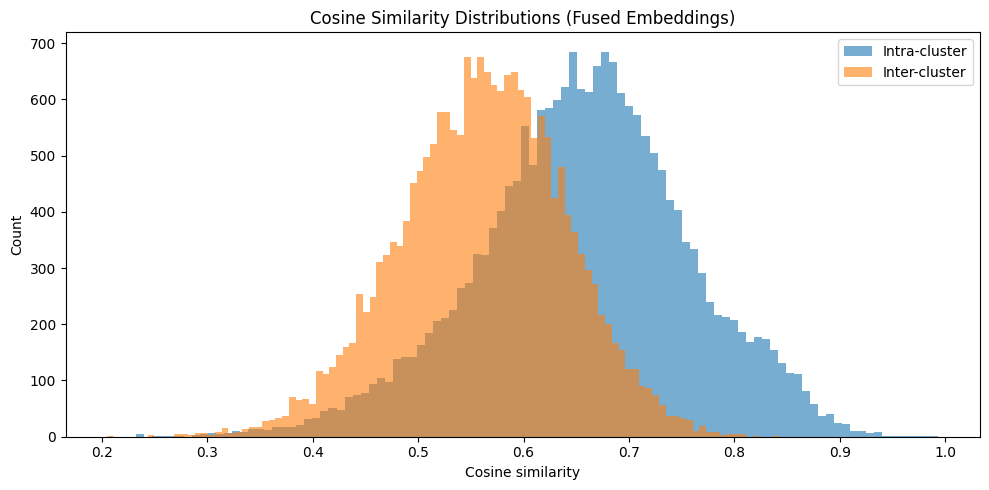

In [30]:

K= 20
plot_similarity_hist(
    cluster_tsv=f"processed_data/clusters/screen_clusters_k{K}.tsv",
    out_png=f"graphs/similarity_hist_k{K}.png",
    out_pdf=f"graphs/similarity_hist_k{K}.pdf",
    n_pairs=20000,
    seed=42,
    bins=100)

### plot category bars

Saved: viz_out\category_r1_bars.png
Saved: viz_out\category_r10_bars.png

Macro averages:
1-gram  R@1 0.12169360520193741 R@10 0.5693110368233889
2-gram  R@1 0.19626774872570774 R@10 0.6283043421396284


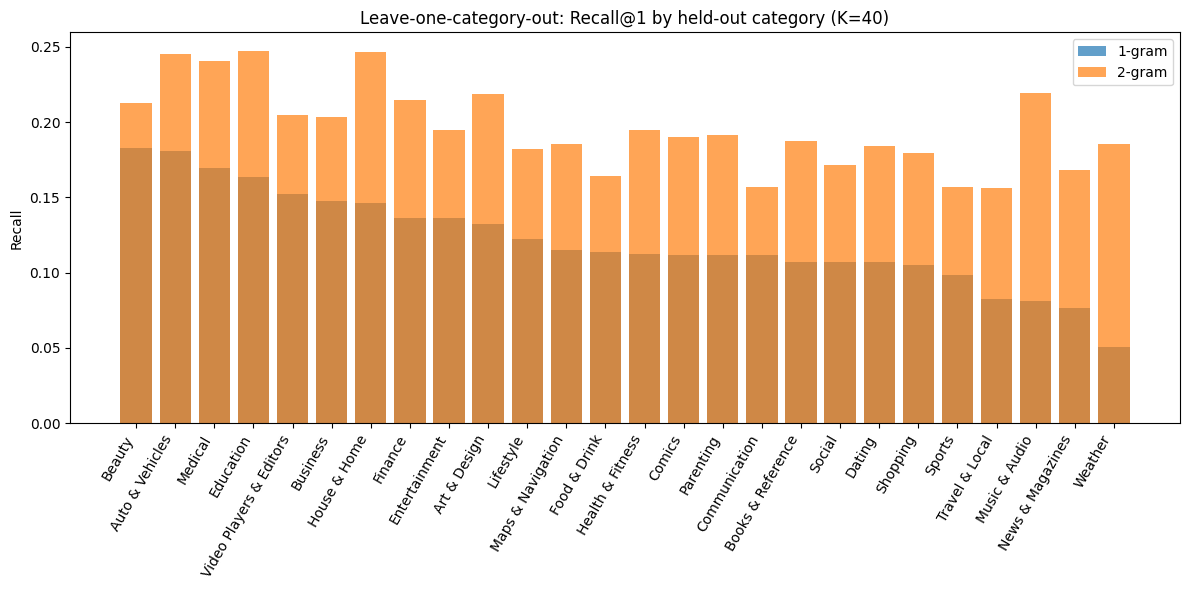

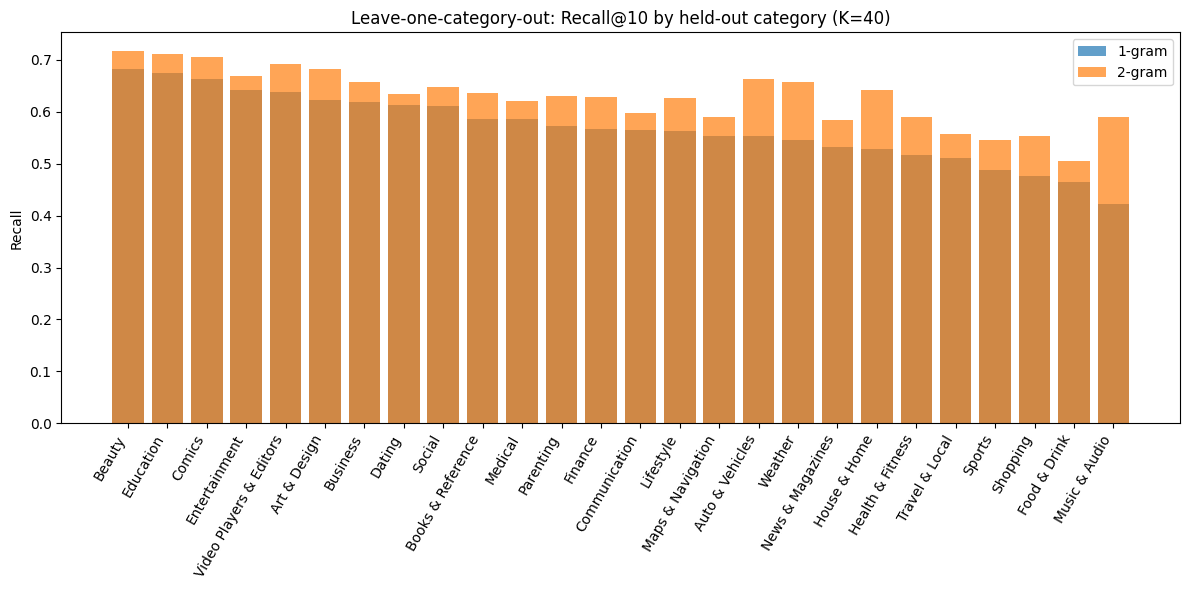

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

def plot_bars(df, metric_col_1g, metric_col_2g, out_path, title):
    # Sort by 1-gram performance for readability
    df = df.sort_values(metric_col_1g, ascending=False)

    cats = df["heldout_category"].tolist()
    y1 = df[metric_col_1g].tolist()
    y2 = df[metric_col_2g].tolist()

    x = range(len(cats))
    plt.figure(figsize=(max(12, len(cats) * 0.35), 6))
    plt.bar(x, y1, alpha=0.7, label="1-gram")
    plt.bar(x, y2, alpha=0.7, label="2-gram")
    plt.xticks(list(x), cats, rotation=60, ha="right")
    plt.ylabel("Recall")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=200)
    print(f"Saved: {out_path}")

def main(
    in_tsv="category_leave_one_out_results.tsv",
    out_dir="viz_out"
):
    os.makedirs(out_dir, exist_ok=True)
    df = pd.read_csv(in_tsv, sep="\t")

    # Required columns check
    required = ["heldout_category", "1g_R1", "2g_R1", "1g_R10", "2g_R10"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns in {in_tsv}: {missing}")

    plot_bars(
        df,
        metric_col_1g="1g_R1",
        metric_col_2g="2g_R1",
        out_path=os.path.join(out_dir, "category_r1_bars.png"),
        title="Leave-one-category-out: Recall@1 by held-out category (K=40)"
    )

    plot_bars(
        df,
        metric_col_1g="1g_R10",
        metric_col_2g="2g_R10",
        out_path=os.path.join(out_dir, "category_r10_bars.png"),
        title="Leave-one-category-out: Recall@10 by held-out category (K=40)"
    )

    # Also print macro means (quick sanity)
    print("\nMacro averages:")
    print("1-gram  R@1", df["1g_R1"].mean(), "R@10", df["1g_R10"].mean())
    print("2-gram  R@1", df["2g_R1"].mean(), "R@10", df["2g_R10"].mean())

if __name__ == "__main__":
    main()


---------------------

### visualize cumulative recall curve  

In [1]:
# ==============================
# Notebook: Recall@k Curves for N-gram Baselines
# ==============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict, Counter
from typing import Dict, List, Tuple

# ------------------------------
# 0) Config
# ------------------------------
DATA_PATH = "processed_data/clusters/screen_clusters_k40.tsv"  # <-- change this
K_LIST = [1, 3, 5, 10,20]
ALPHA_SMOOTH = 1.0
LAMBDA_BACKOFF = 0.2

# If your clusters in the TSV are not 0..K-1 contiguous, we will remap them.
# ------------------------------
# 1) Load traces from TSV
# ------------------------------
def load_traces_tsv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    # Expected columns:
    # screen_key, app_id, trace_id, screen_id, cluster_id
    needed = {"app_id", "trace_id", "cluster_id"}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns in TSV: {missing}. Found: {list(df.columns)}")
    return df

df = load_traces_tsv(DATA_PATH)
df.head()

# ------------------------------
# 2) Build traces per (app_id, trace_id)
# ------------------------------
def build_traces(df: pd.DataFrame, collapse_consecutive_duplicates: bool = True):
    """
    Returns list of tuples: (app_id, trace_id, seq_of_cluster_ids)
    """
    traces = []
    grouped = df.groupby(["app_id", "trace_id"], sort=False)

    for (app_id, trace_id), g in grouped:
        # Preserve original order as in file; if you have a time/order column, sort by it here
        seq = g["cluster_id"].tolist()

        if collapse_consecutive_duplicates and len(seq) > 1:
            collapsed = [seq[0]]
            for x in seq[1:]:
                if x != collapsed[-1]:
                    collapsed.append(x)
            seq = collapsed

        if len(seq) >= 2:
            traces.append((app_id, trace_id, seq))

    return traces

traces_raw = build_traces(df, collapse_consecutive_duplicates=True)
print("Num traces (len>=2):", len(traces_raw))

# ------------------------------
# 3) Remap cluster IDs to 0..K-1 contiguous
# ------------------------------
def remap_clusters(traces):
    all_ids = []
    for _, _, seq in traces:
        all_ids.extend(seq)
    uniq = sorted(set(all_ids))
    id2new = {old:i for i, old in enumerate(uniq)}
    new2old = {i:old for old, i in id2new.items()}

    remapped = []
    for app_id, trace_id, seq in traces:
        remapped.append((app_id, trace_id, [id2new[x] for x in seq]))

    return remapped, id2new, new2old, len(uniq)

traces, id2new, new2old, K = remap_clusters(traces_raw)
print("K (unique clusters observed):", K)

# ------------------------------
# 4) App-split train/test
# ------------------------------
def app_split(traces, test_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    apps = sorted(set(a for a, _, _ in traces))
    rng.shuffle(apps)
    n_test = int(round(len(apps) * test_frac))
    test_apps = set(apps[:n_test])

    train = [t for t in traces if t[0] not in test_apps]
    test  = [t for t in traces if t[0] in test_apps]
    return train, test, test_apps

train_traces, test_traces, test_apps = app_split(traces, test_frac=0.2, seed=42)
print("Train traces:", len(train_traces))
print("Test traces :", len(test_traces))
print("Test apps   :", len(test_apps))

# ------------------------------
# 5) Training: Unigram / Bigram / Trigram (counts)
# ------------------------------
def train_unigram_next(train_traces, K: int, alpha: float = 1.0):
    counts = np.zeros(K, dtype=np.float64)
    for _, _, seq in train_traces:
        for b in seq[1:]:
            counts[b] += 1.0
    counts += alpha
    probs = counts / counts.sum()
    return probs  # shape [K]

def train_bigram_counts(train_traces, K: int, alpha: float = 1.0):
    # counts[a][b] transitions
    counts = np.zeros((K, K), dtype=np.float64)
    for _, _, seq in train_traces:
        for a, b in zip(seq[:-1], seq[1:]):
            counts[a, b] += 1.0
    counts += alpha
    # normalize rows
    probs = counts / counts.sum(axis=1, keepdims=True)
    return probs  # shape [K,K]

def train_trigram_counts(train_traces, K: int, alpha: float = 1.0):
    # counts[(a,b)][c]
    counts = defaultdict(lambda: np.zeros(K, dtype=np.float64))
    for _, _, seq in train_traces:
        if len(seq) < 3:
            continue
        for a, b, c in zip(seq[:-2], seq[1:-1], seq[2:]):
            counts[(a, b)][c] += 1.0

    # apply smoothing to each context that exists
    trigram_probs = {}
    for ctx, vec in counts.items():
        vec = vec + alpha
        trigram_probs[ctx] = vec / vec.sum()
    return trigram_probs  # dict[(a,b)] -> np.array[K]

unigram_probs = train_unigram_next(train_traces, K, alpha=ALPHA_SMOOTH)
bigram_probs  = train_bigram_counts(train_traces, K, alpha=ALPHA_SMOOTH)
trigram_probs = train_trigram_counts(train_traces, K, alpha=ALPHA_SMOOTH)

print("Trigram contexts:", len(trigram_probs))

# ------------------------------
# 6) Backoff scoring for trigram: P(c | a,b) with lambda
#    If trigram context missing -> fallback to bigram row.
#    Use bigram + unigram mixture.
# ------------------------------
def score_next_probs(history_a, history_b, trigram_probs, bigram_probs, unigram_probs,
                     lambda_backoff=0.2):
    """
    Returns probability vector over next cluster, shape [K]
    """
    if (history_a, history_b) in trigram_probs:
        p_tri = trigram_probs[(history_a, history_b)]
        # mix with bigram as extra robustness (optional)
        p_bi = bigram_probs[history_b]
        p = (1 - lambda_backoff) * p_tri + lambda_backoff * p_bi
        return p
    else:
        # no trigram context => bigram + unigram backoff
        p_bi = bigram_probs[history_b]
        p = (1 - lambda_backoff) * p_bi + lambda_backoff * unigram_probs
        return p

# ------------------------------
# 7) Eval: Recall@k (trigram-subset positions only)
# ------------------------------
def eval_recall_at_k_unigram(test_traces, unigram_probs, k_list=(1,3,5,10), trigram_subset=True):
    ranked = np.argsort(-unigram_probs)
    hits = {k: 0 for k in k_list}
    total = 0

    for _, _, seq in test_traces:
        # trigram_subset means only evaluate t>=3 positions (need 2-history),
        # but unigram does not use history; we still align evaluation positions
        start = 2 if trigram_subset else 1
        for t in range(start, len(seq)):
            true_next = seq[t]
            total += 1
            for k in k_list:
                if true_next in ranked[:k]:
                    hits[k] += 1

    recall = {k: (hits[k] / total if total > 0 else 0.0) for k in k_list}
    return recall, total

def eval_recall_at_k_bigram(test_traces, bigram_probs, k_list=(1,3,5,10), trigram_subset=True):
    hits = {k: 0 for k in k_list}
    total = 0

    start = 2 if trigram_subset else 1
    for _, _, seq in test_traces:
        for t in range(start, len(seq)):
            prev = seq[t-1]
            true_next = seq[t]
            probs = bigram_probs[prev]
            ranked = np.argsort(-probs)
            total += 1
            for k in k_list:
                if true_next in ranked[:k]:
                    hits[k] += 1

    recall = {k: (hits[k] / total if total > 0 else 0.0) for k in k_list}
    return recall, total

def eval_recall_at_k_trigram(test_traces, trigram_probs, bigram_probs, unigram_probs,
                            lambda_backoff=0.2, k_list=(1,3,5,10)):
    hits = {k: 0 for k in k_list}
    total = 0

    for _, _, seq in test_traces:
        if len(seq) < 3:
            continue
        for t in range(2, len(seq)):
            a = seq[t-2]
            b = seq[t-1]
            true_next = seq[t]
            probs = score_next_probs(a, b, trigram_probs, bigram_probs, unigram_probs,
                                     lambda_backoff=lambda_backoff)
            ranked = np.argsort(-probs)
            total += 1
            for k in k_list:
                if true_next in ranked[:k]:
                    hits[k] += 1

    recall = {k: (hits[k] / total if total > 0 else 0.0) for k in k_list}
    return recall, total




Num traces (len>=2): 8005
K (unique clusters observed): 40
Train traces: 6397
Test traces : 1608
Test apps   : 1489
Trigram contexts: 1332


In [2]:
clusters_tsv = "processed_data/clusters/screen_clusters_k40.tsv"

Edges evaluated (unigram): 6058
Edges evaluated (bigram) : 6058
Edges evaluated (trigram): 6058
Unigram Recall@k: {1: 0.060911191812479365, 3: 0.15912842522284582, 5: 0.24694618686034994, 10: 0.4517992736876857, 20: 0.7256520303730604}
Bigram  Recall@k: {1: 0.12198745460548036, 3: 0.2692307692307692, 5: 0.38478045559590623, 10: 0.5747771541762958, 20: 0.8172664245625619}
Trigram Recall@k: {1: 0.21492241663915485, 3: 0.3626609442060086, 5: 0.463519313304721, 10: 0.6310663585341697, 20: 0.8367448002641136}


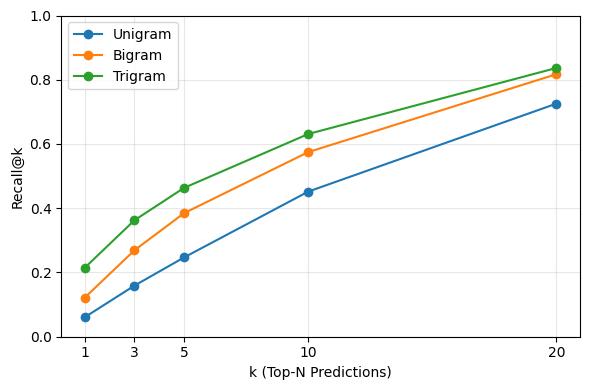

Saved figure: recall_at_k_curve.png


In [4]:
rec_u, tot_u = eval_recall_at_k_unigram(test_traces, unigram_probs, K_LIST, trigram_subset=True)
rec_b, tot_b = eval_recall_at_k_bigram(test_traces, bigram_probs, K_LIST, trigram_subset=True)
rec_t, tot_t = eval_recall_at_k_trigram(test_traces, trigram_probs, bigram_probs, unigram_probs,
                                        lambda_backoff=LAMBDA_BACKOFF, k_list=K_LIST)

print("Edges evaluated (unigram):", tot_u)
print("Edges evaluated (bigram) :", tot_b)
print("Edges evaluated (trigram):", tot_t)

print("Unigram Recall@k:", rec_u)
print("Bigram  Recall@k:", rec_b)
print("Trigram Recall@k:", rec_t)

# ------------------------------
# 8) Plot cumulative Recall@k curves
# ------------------------------
results = {
    "Unigram": rec_u,
    "Bigram":  rec_b,
    "Trigram": rec_t,
}

plt.figure(figsize=(6,4))
for name, rec in results.items():
    y = [rec[k] for k in K_LIST]
    plt.plot(K_LIST, y, marker="o", label=name)

plt.xlabel("k (Top-N Predictions)")
plt.ylabel("Recall@k")
plt.xticks(K_LIST)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = "recall_at_k_curve.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved figure:", out_path)

Edges evaluated (unigram): 6292
Edges evaluated (bigram) : 6292
Edges evaluated (trigram): 6292
Unigram Recall@k: {1: 0.033693579148124604, 3: 0.08598219961856325, 5: 0.12730451366815004, 10: 0.21439923712650985}
Bigram  Recall@k: {1: 0.0875715193897012, 3: 0.19326128417037508, 5: 0.26478067387158294, 10: 0.38922441195168467}
Trigram Recall@k: {1: 0.1217418944691672, 3: 0.2358550540368722, 5: 0.3094405594405594, 10: 0.41926255562619197}


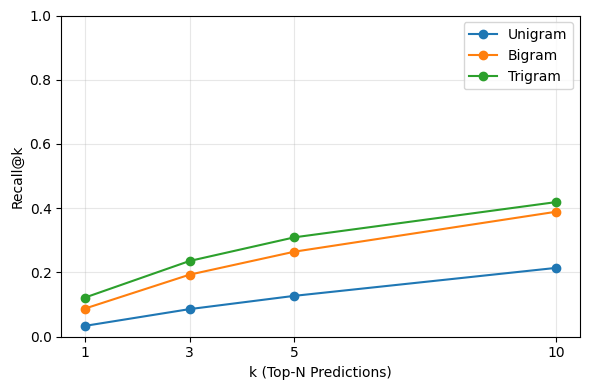

Saved figure: recall_at_k_curve.png


In [39]:
rec_u, tot_u = eval_recall_at_k_unigram(test_traces, unigram_probs, K_LIST, trigram_subset=True)
rec_b, tot_b = eval_recall_at_k_bigram(test_traces, bigram_probs, K_LIST, trigram_subset=True)
rec_t, tot_t = eval_recall_at_k_trigram(test_traces, trigram_probs, bigram_probs, unigram_probs,
                                        lambda_backoff=LAMBDA_BACKOFF, k_list=K_LIST)

print("Edges evaluated (unigram):", tot_u)
print("Edges evaluated (bigram) :", tot_b)
print("Edges evaluated (trigram):", tot_t)

print("Unigram Recall@k:", rec_u)
print("Bigram  Recall@k:", rec_b)
print("Trigram Recall@k:", rec_t)

# ------------------------------
# 8) Plot cumulative Recall@k curves
# ------------------------------
results = {
    "Unigram": rec_u,
    "Bigram":  rec_b,
    "Trigram": rec_t,
}

plt.figure(figsize=(6,4))
for name, rec in results.items():
    y = [rec[k] for k in K_LIST]
    plt.plot(K_LIST, y, marker="o", label=name)

plt.xlabel("k (Top-N Predictions)")
plt.ylabel("Recall@k")
plt.xticks(K_LIST)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = "recall_at_k_curve.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved figure:", out_path)

Edges evaluated (unigram): 6058
Edges evaluated (bigram) : 6058
Edges evaluated (trigram): 6058
Unigram Recall@k: {1: 0.060911191812479365, 3: 0.15912842522284582, 5: 0.24694618686034994, 10: 0.4517992736876857, 20: 0.7256520303730604}
Bigram  Recall@k: {1: 0.12198745460548036, 3: 0.2692307692307692, 5: 0.38478045559590623, 10: 0.5747771541762958, 20: 0.8172664245625619}
Trigram Recall@k: {1: 0.21492241663915485, 3: 0.3626609442060086, 5: 0.463519313304721, 10: 0.6310663585341697, 20: 0.8367448002641136}


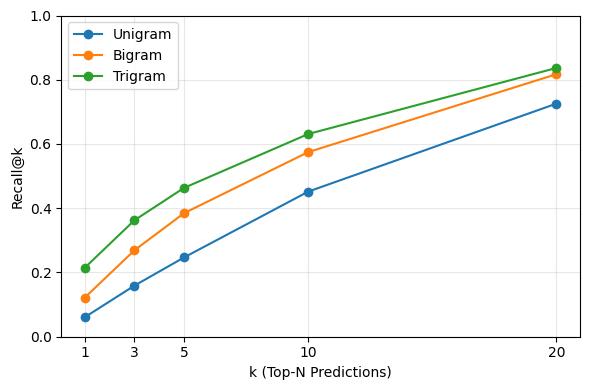

Saved figure: recall_at_k_curve.png


In [3]:
rec_u, tot_u = eval_recall_at_k_unigram(test_traces, unigram_probs, K_LIST, trigram_subset=True)
rec_b, tot_b = eval_recall_at_k_bigram(test_traces, bigram_probs, K_LIST, trigram_subset=True)
rec_t, tot_t = eval_recall_at_k_trigram(test_traces, trigram_probs, bigram_probs, unigram_probs,
                                        lambda_backoff=LAMBDA_BACKOFF, k_list=K_LIST)

print("Edges evaluated (unigram):", tot_u)
print("Edges evaluated (bigram) :", tot_b)
print("Edges evaluated (trigram):", tot_t)

print("Unigram Recall@k:", rec_u)
print("Bigram  Recall@k:", rec_b)
print("Trigram Recall@k:", rec_t)

# ------------------------------
# 8) Plot cumulative Recall@k curves
# ------------------------------
results = {
    "Unigram": rec_u,
    "Bigram":  rec_b,
    "Trigram": rec_t,
}

plt.figure(figsize=(6,4))
for name, rec in results.items():
    y = [rec[k] for k in K_LIST]
    plt.plot(K_LIST, y, marker="o", label=name)

plt.xlabel("k (Top-N Predictions)")
plt.ylabel("Recall@k")
plt.xticks(K_LIST)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = "recall_at_k_curve.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved figure:", out_path)

In [40]:
clusters_tsv = "processed_data/clusters/screen_clusters_k110.tsv"

Edges evaluated (unigram): 6058
Edges evaluated (bigram) : 6058
Edges evaluated (trigram): 6058
Unigram Recall@k: {1: 0.060911191812479365, 3: 0.15912842522284582, 5: 0.24694618686034994, 10: 0.4517992736876857}
Bigram  Recall@k: {1: 0.12198745460548036, 3: 0.2692307692307692, 5: 0.38478045559590623, 10: 0.5747771541762958}
Trigram Recall@k: {1: 0.21492241663915485, 3: 0.3626609442060086, 5: 0.463519313304721, 10: 0.6310663585341697}


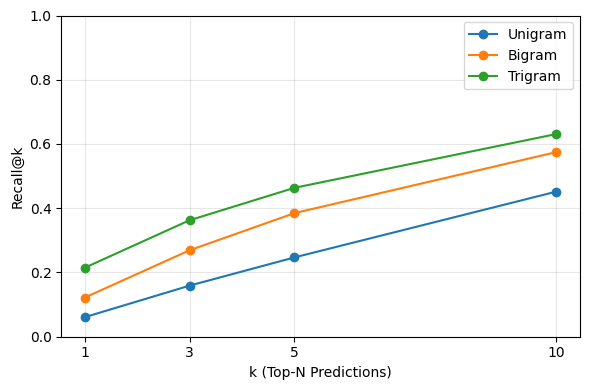

Saved figure: recall_at_k_curve40.png


In [43]:
rec_u, tot_u = eval_recall_at_k_unigram(test_traces, unigram_probs, K_LIST, trigram_subset=True)
rec_b, tot_b = eval_recall_at_k_bigram(test_traces, bigram_probs, K_LIST, trigram_subset=True)
rec_t, tot_t = eval_recall_at_k_trigram(test_traces, trigram_probs, bigram_probs, unigram_probs,
                                        lambda_backoff=LAMBDA_BACKOFF, k_list=K_LIST)

print("Edges evaluated (unigram):", tot_u)
print("Edges evaluated (bigram) :", tot_b)
print("Edges evaluated (trigram):", tot_t)

print("Unigram Recall@k:", rec_u)
print("Bigram  Recall@k:", rec_b)
print("Trigram Recall@k:", rec_t)

# ------------------------------
# 8) Plot cumulative Recall@k curves
# ------------------------------
results = {
    "Unigram": rec_u,
    "Bigram":  rec_b,
    "Trigram": rec_t,
}

plt.figure(figsize=(6,4))
for name, rec in results.items():
    y = [rec[k] for k in K_LIST]
    plt.plot(K_LIST, y, marker="o", label=name)

plt.xlabel("k (Top-N Predictions)")
plt.ylabel("Recall@k")
plt.xticks(K_LIST)
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

out_path = "recall_at_k_curve40.png"
plt.savefig(out_path, dpi=300)
plt.show()

print("Saved figure:", out_path)

In [73]:
print(len(test_traces[0]))
print(len(test_traces[0][2]))
for k in range (len(test_traces)):
    if (len(test_traces[k][2]) == 1):
        print(len(test_traces[k][2]))

3
2


In [61]:
print(test_traces[2])
print(prob_next("trigram", test_traces[2][2], 2))

('air.com.readysquare.scsm', 'trace_0', [8, 23, 29])
0.014393282971894412


In [83]:
for k in range(1,len(test_traces)):
    _,_, seq = test_traces[k]
    if len(seq) <= 2:
        continue
    pr= prob_next("trigram", test_traces[k][2], 2)
    if (pr >0.4):
        print(pr)
        print(test_traces[k][2])
        

0.40940348616806455
[30, 28, 30, 5, 9, 15, 9, 5, 3, 10, 30, 15, 30, 15, 9, 39, 28]
0.40940348616806455
[30, 28, 30, 20, 30, 23, 30, 23, 20, 3, 30, 20, 30, 28, 20]


Built anomaly dataset for model=trigram
  normal examples   : 6058
  corrupted examples: 6058
  total             : 12116
  positive rate     : 0.5000
Average Precision (AP) ≈ 0.7466


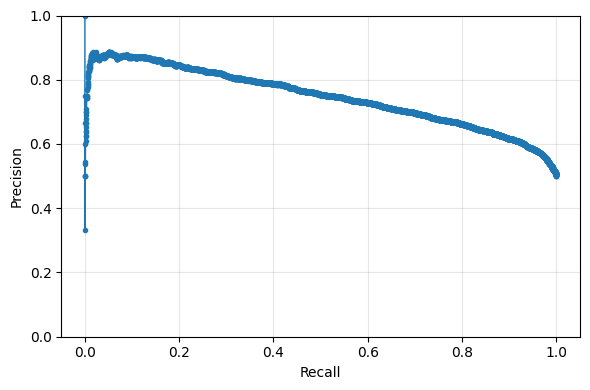

Saved: pr_curve_trigram.png
Top-50 alerts: threshold=5.2467 | Precision=0.8039 | Recall=0.0068
Top-100 alerts: threshold=5.0798 | Precision=0.8800 | Recall=0.0145
Top-200 alerts: threshold=4.9560 | Precision=0.8657 | Recall=0.0287


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
RNG_SEED = 42
NUM_CORRUPT_PER_EDGE = 1   # 1 corrupted example per normal edge
EPS = 1e-12

# Choose model for scoring: "unigram", "bigram", or "trigram"
MODEL_FOR_ANOMALY = "trigram"   # <-- recommended (strongest baseline)
LAMBDA_BACKOFF = 0.2            # use same as your recall experiments

rng = np.random.default_rng(RNG_SEED)

# -----------------------------
# Helper: get probability of a candidate next state
# -----------------------------
def prob_next(model_name, seq, t):
    """
    Returns P_model(next=seq[t] | history) for position t (t>=1 for bigram, t>=2 for trigram)
    seq[t] is the "next"
    """
    c = seq[t]

    if model_name == "unigram":
        return float(unigram_probs[c])

    elif model_name == "bigram":
        b = seq[t-1]
        return float(bigram_probs[b, c])

    elif model_name == "trigram":
        a = seq[t-2]
        b = seq[t-1]
        probs = score_next_probs(
            a, b,
            trigram_probs=trigram_probs,
            bigram_probs=bigram_probs,
            unigram_probs=unigram_probs,
            lambda_backoff=LAMBDA_BACKOFF
        )
        return float(probs[c])

    else:
        raise ValueError(f"Unknown model_name={model_name}")




# -----------------------------
# 1) Build anomaly dataset: normal edges + corrupted edges
# -----------------------------
def build_scores_labels_from_test_traces(test_traces, K, model_name="trigram",
                                        num_corrupt_per_edge=1,
                                        trigram_subset_only=True):
    """
    Creates arrays:
      - scores: -log P_model(c|history)
      - labels: 0 for normal, 1 for corrupted
    Corruption: replace the true next cluster with a random different cluster.
    """
    scores = []
    labels = []

    total_normal = 0
    total_corrupt = 0

    for _, _, seq in test_traces:
        # Determine start index based on model/history needs
        if model_name == "unigram":
            start = 2 if trigram_subset_only else 1  # to match context positions if desired
        elif model_name == "bigram":
            start = 2 if trigram_subset_only else 1
        elif model_name == "trigram":
            start = 2
        else:
            raise ValueError(model_name)

        if len(seq) <= start:
            continue

        for t in range(start, len(seq)):
            true_next = seq[t]

            # --- Normal example ---
            p = prob_next(model_name, seq, t)
            score = -np.log(p + EPS)
            scores.append(score)
            labels.append(0)
            total_normal += 1

            # --- Corrupted examples ---
            for _ in range(num_corrupt_per_edge):
                # sample a wrong next cluster
                wrong = rng.integers(0, K)
                while wrong == true_next:
                    wrong = rng.integers(0, K)

                # temporarily swap the next state for scoring
                original = seq[t]
                seq[t] = wrong
                p_wrong = prob_next(model_name, seq, t)
                seq[t] = original

                score_wrong = -np.log(p_wrong + EPS)
                scores.append(score_wrong)
                labels.append(1)
                total_corrupt += 1

    scores = np.array(scores, dtype=np.float64)
    labels = np.array(labels, dtype=np.int32)

    print(f"Built anomaly dataset for model={model_name}")
    print(f"  normal examples   : {total_normal}")
    print(f"  corrupted examples: {total_corrupt}")
    print(f"  total             : {len(labels)}")
    print(f"  positive rate     : {labels.mean():.4f}")
    return scores, labels

scores, labels = build_scores_labels_from_test_traces(
    test_traces=test_traces,
    K=K,
    model_name=MODEL_FOR_ANOMALY,
    num_corrupt_per_edge=NUM_CORRUPT_PER_EDGE,
    trigram_subset_only=True
)

# -----------------------------
# 2) Manual Precision–Recall curve + AP
# -----------------------------
def precision_recall_curve_manual(y_true, y_score):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    order = np.argsort(-y_score)
    y_true = y_true[order]
    y_score = y_score[order]

    P = y_true.sum()
    if P == 0:
        raise ValueError("No positives; PR undefined.")

    tp = 0
    fp = 0

    precision = []
    recall = []
    thresholds = []

    prev_score = None
    for i in range(len(y_score)):
        s = y_score[i]
        if prev_score is None or s != prev_score:
            if (tp + fp) > 0:
                precision.append(tp / (tp + fp))
                recall.append(tp / P)
                thresholds.append(s)
            prev_score = s

        if y_true[i] == 1:
            tp += 1
        else:
            fp += 1

    precision.append(tp / (tp + fp))
    recall.append(tp / P)
    thresholds.append(y_score[-1])

    return np.array(precision), np.array(recall), np.array(thresholds)

def average_precision_trapz(precision, recall):
    order = np.argsort(recall)
    r = recall[order]
    p = precision[order]
    return np.trapz(p, r)

prec, rec, thr = precision_recall_curve_manual(labels, scores)
ap = average_precision_trapz(prec, rec)

print(f"Average Precision (AP) ≈ {ap:.4f}")

plt.figure(figsize=(6,4))
plt.plot(rec, prec, marker=".", linewidth=1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim(0, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"pr_curve_{MODEL_FOR_ANOMALY}.png", dpi=300)
plt.show()

print(f"Saved: pr_curve_{MODEL_FOR_ANOMALY}.png")

# -----------------------------
# 3) Practical threshold: "top-N alerts" (global)
# -----------------------------
def precision_recall_at_topN(scores, labels, N):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)

    if N <= 0:
        raise ValueError("N must be positive.")
    N = min(N, len(scores))

    # threshold is Nth largest score
    t = np.sort(scores)[-N]
    pred = (scores >= t).astype(int)

    tp = ((pred == 1) & (labels == 1)).sum()
    fp = ((pred == 1) & (labels == 0)).sum()
    fn = ((pred == 0) & (labels == 1)).sum()

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    return t, precision, recall

for N in [50, 100, 200]:
    t, p, r = precision_recall_at_topN(scores, labels, N)
    print(f"Top-{N} alerts: threshold={t:.4f} | Precision={p:.4f} | Recall={r:.4f}")


In [86]:
CORRUPT_RATE = 0.01  # try 0.10, 0.05, 0.01
rng = np.random.default_rng(42)

def build_scores_labels_rare_anomalies(test_traces, K, model_name="trigram",
                                      corrupt_rate=0.05, trigram_subset_only=True):
    scores, labels = [], []
    total_normal = total_corrupt = 0

    for _, _, seq in test_traces:
        start = 2  # trigram positions only
        if len(seq) <= start:
            continue

        for t in range(start, len(seq)):
            true_next = seq[t]

            # normal
            p = prob_next(model_name, seq, t)
            scores.append(-np.log(p + 1e-12))
            labels.append(0)
            total_normal += 1

            # corrupt with probability = corrupt_rate
            if rng.random() < corrupt_rate:
                wrong = rng.integers(0, K)
                while wrong == true_next:
                    wrong = rng.integers(0, K)

                original = seq[t]
                seq[t] = wrong
                p_wrong = prob_next(model_name, seq, t)
                seq[t] = original

                scores.append(-np.log(p_wrong + 1e-12))
                labels.append(1)
                total_corrupt += 1

    scores = np.array(scores, dtype=np.float64)
    labels = np.array(labels, dtype=np.int32)

    print(f"Rare anomaly dataset (rate={corrupt_rate})")
    print(f"  normal   : {total_normal}")
    print(f"  corrupt  : {total_corrupt}")
    print(f"  positive rate: {labels.mean():.4f}")
    return scores, labels

scores_5, labels_5 = build_scores_labels_rare_anomalies(
    test_traces, K, model_name="trigram", corrupt_rate=CORRUPT_RATE
)


Rare anomaly dataset (rate=0.01)
  normal   : 6058
  corrupt  : 56
  positive rate: 0.0092


Rare anomaly dataset (rate=0.01)
  normal   : 6058
  corrupt  : 65
  positive rate: 0.0106


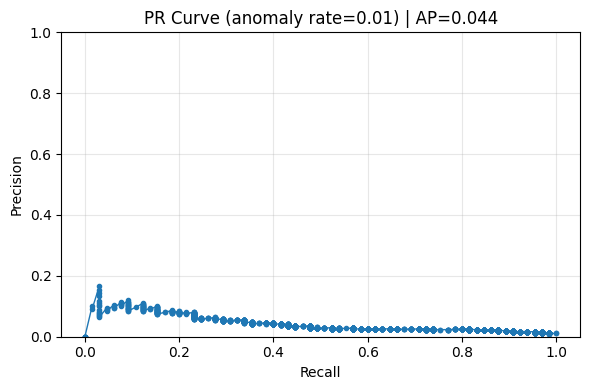

Rare anomaly dataset (rate=0.05)
  normal   : 6058
  corrupt  : 296
  positive rate: 0.0466


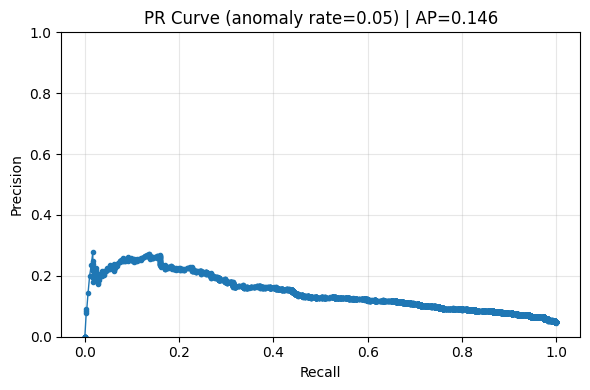

Rare anomaly dataset (rate=0.1)
  normal   : 6058
  corrupt  : 618
  positive rate: 0.0926


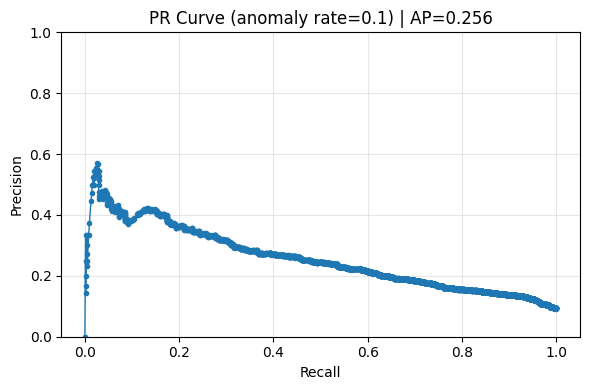

,rate,AP,TopN,threshold,precision,recall,num_pos,num_total
0,0.01,0.044060,5,5.576870,0.00,0.000000,65,6123
1,0.01,0.044060,10,5.357554,0.10,0.015385,65,6123
2,0.01,0.044060,20,5.016894,0.10,0.030769,65,6123
3,0.01,0.044060,50,4.778587,0.12,0.092308,65,6123
4,0.01,0.044060,100,4.601550,0.10,0.153846,65,6123
5,0.05,0.146449,5,5.576870,0.00,0.000000,296,6354
6,0.05,0.146449,10,5.354671,0.00,0.000000,296,6354
7,0.05,0.146449,20,5.052122,0.25,0.016892,296,6354
8,0.05,0.146449,50,4.828187,0.20,0.033784,296,6354
9,0.05,0.146449,100,4.648312,0.25,0.084459,296,6354


In [89]:
rates = [0.01, 0.05, 0.10]
topN_list = [5, 10, 20, 50, 100]

all_summary = []

for rate in rates:
    scores, labels = build_scores_labels_rare_anomalies(
        test_traces=test_traces,
        K=K,
        model_name="trigram",
        corrupt_rate=rate,      # now treated as probability
        trigram_subset_only=True
    )

    prec, rec, thr = precision_recall_curve_manual(labels, scores)
    ap = average_precision_trapz(prec, rec)

    # Plot PR curve
    plt.figure(figsize=(6,4))
    plt.plot(rec, prec, marker=".", linewidth=1)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.title(f"PR Curve (anomaly rate={rate}) | AP={ap:.3f}")
    plt.tight_layout()
    plt.savefig(f"pr_curve_rate_{rate}.png", dpi=300)
    plt.show()

    # Top-N alert metrics
    for N in topN_list:
        t, p_atN, r_atN = precision_recall_at_topN(scores, labels, N)
        all_summary.append({
            "rate": rate,
            "AP": ap,
            "TopN": N,
            "threshold": float(t),
            "precision": float(p_atN),
            "recall": float(r_atN),
            "num_pos": int(labels.sum()),
            "num_total": int(len(labels))
        })

# Convert to DataFrame for a clean table
import pandas as pd
summary_df = pd.DataFrame(all_summary)
summary_df


In [1]:
import numpy as np
from collections import defaultdict

def per_app_topN_metrics(scores, labels, app_ids, N):
    scores = np.asarray(scores)
    labels = np.asarray(labels).astype(int)
    app_ids = np.asarray(app_ids)

    apps = np.unique(app_ids)
    per_app = []

    for a in apps:
        idx = np.where(app_ids == a)[0]
        if len(idx) == 0:
            continue

        s = scores[idx]
        y = labels[idx]

        # If no positives in this app, skip for recall; still can count precision if you want
        if y.sum() == 0:
            continue

        n = min(N, len(s))
        top_idx = np.argsort(-s)[:n]
        pred = np.zeros_like(y)
        pred[top_idx] = 1

        tp = ((pred == 1) & (y == 1)).sum()
        fp = ((pred == 1) & (y == 0)).sum()
        fn = ((pred == 0) & (y == 1)).sum()

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)

        per_app.append((precision, recall, int(y.sum()), len(y)))

    if not per_app:
        return None

    precs = np.array([p for p, r, pos, m in per_app])
    recs  = np.array([r for p, r, pos, m in per_app])

    return {
        "N": N,
        "num_apps": len(per_app),
        "precision_mean": float(precs.mean()),
        "precision_median": float(np.median(precs)),
        "recall_mean": float(recs.mean()),
        "recall_median": float(np.median(recs)),
    }

# Example usage:
# for N in [1,3,5,10]:
#     print(per_app_topN_metrics(scores, labels, app_ids, N))


In [2]:
for N in [1,3,5,10]:
     print(per_app_topN_metrics(scores, labels, app_ids, N))


NameError: name 'scores' is not defined